# Lab 3: Data Cleaning

#### Objective

The objective of this lab is to transform raw, messy data into a clean and reliable dataset through systematic data-cleaning techniques.

The following tasks are performed:

1. Profile missing values by count and percentage.
2. Select appropriate strategies for handling missing values.
3. Identify and correct incorrect data types.
4. Detect and handle duplicate records.
5. Identify and assess potential outliers.
6. Validate the cleaned dataset for consistency and sensible value ranges.

Each cleaning decision is supported by a short rationale rather than applying transformations blindly.

### Task 1: Missing Profile

#### Step 1.1: Load and Inspect the Dataset

The dataset is loaded and its basic structure is examined before performing missing-value analysis.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/WineQT.csv")

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [2]:
df.shape

(1143, 13)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [4]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


#### Step 1.2: Missing Value Count

The number of missing values in each column is calculated to identify columns containing incomplete observations.

In [6]:
missing_count = df.isnull().sum()

missing_count

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

#### Step 1.3: Missing Value Percentage

The percentage of missing values in each column is calculated relative to the total number of observations.

In [8]:
missing_percentage = (df.isnull().sum() / len(df) * 100).round(2)

missing_percentage

fixed acidity           0.0
volatile acidity        0.0
citric acid             0.0
residual sugar          0.0
chlorides               0.0
free sulfur dioxide     0.0
total sulfur dioxide    0.0
density                 0.0
pH                      0.0
sulphates               0.0
alcohol                 0.0
quality                 0.0
Id                      0.0
dtype: float64

#### Step 1.4: Missingness Summary

The missing-value count and percentage are combined into a single summary table for easier interpretation.

In [9]:
missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

missing_summary

,Missing Count,Missing Percentage
fixed acidity,0,0.0
volatile acidity,0,0.0
citric acid,0,0.0
residual sugar,0,0.0
chlorides,0,0.0
free sulfur dioxide,0,0.0
total sulfur dioxide,0,0.0
density,0,0.0
pH,0,0.0
sulphates,0,0.0


### Step 1.5: Overall Missing Value Check

The total number of missing values across the dataset is calculated to determine whether missing-value treatment is required.

In [10]:
total_missing = df.isnull().sum().sum()

print("Total missing values:", total_missing)

Total missing values: 0


### Task 2 — Missing Value Strategy

#### Step 2.1: Identify Columns Requiring Treatment

The missing-value summary is reviewed to identify columns that require a missing-value handling strategy.

In [12]:
columns_with_missing = missing_summary[
    missing_summary["Missing Count"] > 0
]

columns_with_missing

,Missing Count,Missing Percentage


#### Step 2.2: Select Appropriate Strategy

The missing-value handling strategy is selected based on the missingness identified in the dataset. Since no missing values are present, no imputation or row/column deletion is required.

In [13]:
if columns_with_missing.empty:
    print("No missing-value treatment is required.")
else:
    print("Missing-value treatment is required for the identified columns.")

No missing-value treatment is required.


#### Step 2.3: Apply Missing Value Treatment

No missing-value treatment is applied because the dataset contains no missing observations. The original data is therefore retained without imputation or deletion.

In [15]:
df_cleaned = df.copy()

print("Missing-value treatment: Not required")

Missing-value treatment: Not required


#### Step 2.4: Verify Missing Values

The cleaned dataset is checked again to confirm that no missing values remain after the missing-value handling process.

In [16]:
df_cleaned.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [17]:
print("Total missing values after cleaning:", df_cleaned.isnull().sum().sum())

Total missing values after cleaning: 0


### Task 3 — Data Type Validation

#### Step 3.1: Check Current Data Types

The data types of all columns are examined to identify any inconsistencies or incorrect representations that may affect further analysis.

In [18]:
df_cleaned.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object

In [19]:
df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


#### Step 3.2: Identify Incorrect Data Types

The existing data types are reviewed to determine whether any columns require conversion for accurate analysis and processing.

Numerical columns should be stored as appropriate integer or floating-point types, while categorical columns should be stored as object or category types.

In [20]:
# Display columns with their data types
data_types = pd.DataFrame({
    "Column": df_cleaned.columns,
    "Data Type": df_cleaned.dtypes.values
})

data_types

,Column,Data Type
0,fixed acidity,float64
1,volatile acidity,float64
2,citric acid,float64
3,residual sugar,float64
4,chlorides,float64
5,free sulfur dioxide,float64
6,total sulfur dioxide,float64
7,density,float64
8,pH,float64
9,sulphates,float64


In [21]:
df_cleaned.select_dtypes(include="object").columns

Index([], dtype='str')

#### Step 3.3: Convert Data Types (if required)

The identified data types are reviewed and converted only when necessary. Unnecessary conversions are avoided to preserve the original data integrity.

In [22]:
# Create a copy before applying datatype changes
df_cleaned = df_cleaned.copy()

# Display current data types after validation
df_cleaned.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object

#### Step 3.4: Verify Data Types

The data types of the cleaned dataset are verified after the validation process to ensure that all columns are stored in appropriate formats.

In [23]:
df_cleaned.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object

In [24]:
df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


### Task 4 — Duplicate Detection and Handling

#### Step 4.1: Identify Duplicate Records

Duplicate records are identified to ensure that repeated observations do not affect statistical analysis and model performance.

In [25]:
duplicate_rows = df_cleaned[df_cleaned.duplicated()]

duplicate_rows

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id


#### Step 4.2: Count Duplicate Rows

The total number of duplicate records in the dataset is calculated to determine whether duplicate removal is required.

In [27]:
duplicate_count = df_cleaned.duplicated().sum()

print("Total duplicate rows:", duplicate_count)

Total duplicate rows: 0


#### Step 4.3: Remove Duplicate Records (if required)

Duplicate records are removed from the dataset to prevent repeated observations from influencing further analysis.

A new cleaned dataset is created while preserving the original dataset for reference.

In [28]:
# Remove duplicate rows
df_cleaned = df_cleaned.drop_duplicates()

# Check new dataset size
df_cleaned.shape

(1143, 13)

In [29]:
print("Rows after duplicate removal:", len(df_cleaned))

Rows after duplicate removal: 1143


#### Step 4.4: Verify Duplicate Removal

The cleaned dataset is checked again to confirm that all duplicate records have been successfully removed.

In [30]:
remaining_duplicates = df_cleaned.duplicated().sum()

print("Remaining duplicate rows:", remaining_duplicates)

Remaining duplicate rows: 0


In [31]:
print("Cleaned dataset shape:", df_cleaned.shape)

Cleaned dataset shape: (1143, 13)


### Task 5 — Outlier Detection and Handling

#### Step 5.1: Statistical Summary of Numerical Features

A statistical summary of numerical features is generated to understand the distribution and identify potential extreme values.

In [32]:
df_cleaned.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


#### Step 5.2: Detect Outliers Using IQR Method

The Interquartile Range (IQR) method is used to identify potential outliers in numerical features.

Values below the lower bound or above the upper bound are considered potential outliers.

Formula:

- IQR = Q3 - Q1
- Lower Bound = Q1 - 1.5 × IQR
- Upper Bound = Q3 + 1.5 × IQR

In [33]:
# Select numerical columns
numerical_columns = df_cleaned.select_dtypes(include=np.number).columns

outlier_summary = {}

for column in numerical_columns:
    Q1 = df_cleaned[column].quantile(0.25)
    Q3 = df_cleaned[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_cleaned[
        (df_cleaned[column] < lower_bound) |
        (df_cleaned[column] > upper_bound)
    ]
    
    outlier_summary[column] = len(outliers)

outlier_summary

{'fixed acidity': 44,
 'volatile acidity': 14,
 'citric acid': 1,
 'residual sugar': 110,
 'chlorides': 77,
 'free sulfur dioxide': 18,
 'total sulfur dioxide': 40,
 'density': 36,
 'pH': 20,
 'sulphates': 43,
 'alcohol': 12,
 'quality': 22,
 'Id': 0}

#### Step 5.3: Visualize Outliers Using Boxplots

Boxplots are used to visually identify the presence of potential outliers in numerical features.

The points outside the whiskers represent observations that may be considered outliers based on the IQR method.

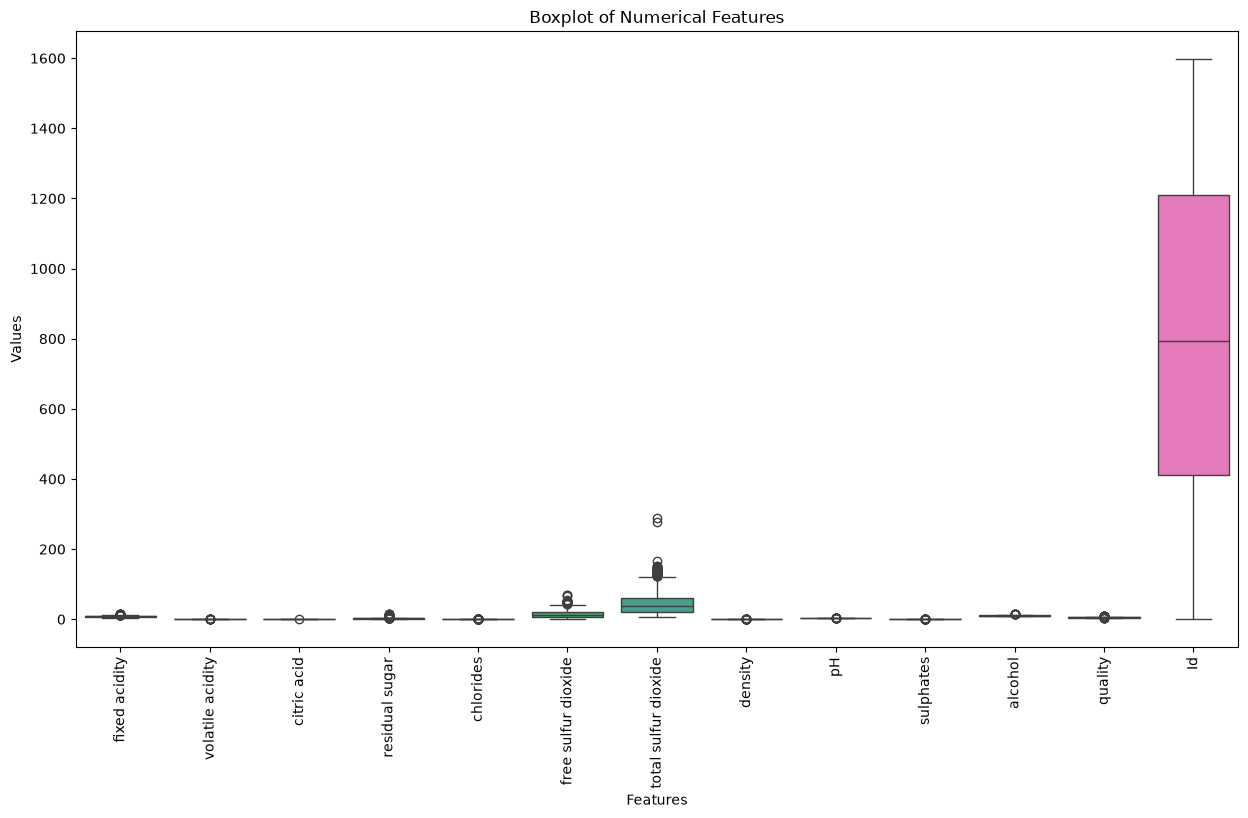

In [36]:
plt.figure(figsize=(15,8))

sns.boxplot(data=df_cleaned)

plt.xticks(rotation=90)
plt.title("Boxplot of Numerical Features")
plt.xlabel("Features")
plt.ylabel("Values")

plt.show()

#### Observation

The boxplot analysis shows the distribution and presence of potential outliers across numerical features.

Some features contain observations beyond the whiskers, indicating possible outliers according to the IQR method. However, these values were not removed directly because extreme chemical measurements in the Wine Quality dataset may represent valid variations rather than data errors.

Further outlier treatment decisions are made based on feature behavior and their impact on analysis.

#### Step 5.4: Decide Outlier Treatment Strategy

The identified outliers are evaluated to determine the appropriate handling strategy.

Outliers are not automatically removed because extreme values in chemical properties may represent genuine variations in wine characteristics rather than incorrect data entries.

Therefore, the identified outliers are retained to preserve the original information and avoid loss of potentially valuable observations.

In [38]:
# Retaining outliers after analysis

df_final = df_cleaned.copy()

print("Outlier treatment strategy: Outliers retained")

Outlier treatment strategy: Outliers retained


#### Step 5.5: Verify Dataset After Treatment

The dataset is verified after the outlier handling decision to ensure that no unintended changes have been introduced and that the dataset structure remains consistent.

In [39]:
df_final.shape

(1143, 13)

In [40]:
df_final.isnull().sum().sum()

np.int64(0)

In [41]:
df_final.duplicated().sum()

np.int64(0)

In [42]:
df_final.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object

### Task 6 — Final Dataset Validation and Summary

#### Step 6.1: Check Dataset Shape

The dimensions of the final cleaned dataset are checked to confirm the number of observations and features available after preprocessing.

In [43]:
df_final.shape

(1143, 13)

#### Step 6.2: Check Missing Values

The final dataset is checked for missing values to ensure that no incomplete observations remain after the cleaning process.

In [45]:
df_final.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [46]:
print("Total missing values:", df_final.isnull().sum().sum())

Total missing values: 0


#### Step 6.3: Check Duplicate Records

The final dataset is checked for duplicate records to confirm that each observation is unique.

In [48]:
print("Duplicate rows:", df_final.duplicated().sum())

Duplicate rows: 0


#### Step 6.4: Check Data Types

The data types of the final dataset are verified to ensure that all features are stored in appropriate formats.

In [50]:
df_final.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object

#### Step 6.5: Compare Before and After Cleaning

The original and final cleaned datasets are compared to understand the changes introduced during the data-cleaning process.

In [51]:
comparison = pd.DataFrame({
    "Dataset": ["Original Dataset", "Cleaned Dataset"],
    "Rows": [df.shape[0], df_final.shape[0]],
    "Columns": [df.shape[1], df_final.shape[1]]
})

comparison

,Dataset,Rows,Columns
0,Original Dataset,1143,13
1,Cleaned Dataset,1143,13


In [52]:
removed_rows = df.shape[0] - df_final.shape[0]

print("Rows removed during cleaning:", removed_rows)

Rows removed during cleaning: 0


## Overall Observation

Throughout Lab 1, Lab 2, and Lab 3, the fundamentals of data processing and analysis were explored using Python and essential data science libraries.

In Lab 1, basic Pandas operations were performed to understand data loading, inspection, indexing, filtering, and basic statistical analysis. The dataset structure, feature characteristics, and summary statistics were analyzed to build a foundation for further processing.

In Lab 2, NumPy concepts were explored, including array creation, indexing, mathematical operations, vectorization, and performance comparison between traditional Python loops and optimized NumPy operations. The analysis demonstrated the efficiency of vectorized computations for handling large-scale numerical data.

In Lab 3, data cleaning techniques were implemented to improve dataset quality. The dataset was evaluated for missing values, incorrect data types, duplicate records, and potential outliers. Appropriate cleaning strategies were applied, and the final dataset was validated to ensure consistency and reliability.

Overall, these labs provided practical understanding of the complete data preprocessing workflow, starting from raw data inspection to cleaning and optimization. The processed dataset is now prepared for further exploratory data analysis and machine learning tasks.